<a href="https://colab.research.google.com/github/sb24ragnar/hackathon_R_Methods_Group_G/blob/main/23108363.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing all the necessary libraries

In [243]:
import pandas as pd # For data manipulation and analysis
import numpy as np # For numerical operations
# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
# Scikit-learn: Model selection and evaluation
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, mean_squared_error
# Scikit-learn: Preprocessing and imputation
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer # For multivariate imputation by chained equations (MICE).
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline # For chaining multiple processing steps together in a streamlined workflow.
# XGBoost: Gradient Boosting library
import xgboost as xgb
import re # Import regular expression module

In [213]:
datapath = "https://raw.githubusercontent.com/sb24ragnar/hackathon_R_Methods/refs/heads/main/dataset_A_training.csv"
df = pd.read_csv(datapath)
df.head()

,respondent_id,flu_concern,flu_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,seasonal_vaccine
0,1,2.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,0.0,0.0,entertainment,0
1,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Male,NaN,Not Married,Rent,Employed,"MSA, Principle City",1.0,0.0,education,0
2,3,2.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,...,Male,"> $75,000",Married,Own,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,NaN,0
3,4,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Male,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",1.0,2.0,utilities,1
4,5,2.0,2.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,...,Female,Below Poverty,Not Married,Rent,Not in Labor Force,"MSA, Not Principle City",2.0,0.0,NaN,0


In [215]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4756 entries, 0 to 4755
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                4756 non-null   int64  
 1   flu_concern                  4744 non-null   float64
 2   flu_knowledge                4733 non-null   float64
 3   behavioral_antiviral_meds    4742 non-null   float64
 4   behavioral_avoidance         4724 non-null   float64
 5   behavioral_face_mask         4753 non-null   float64
 6   behavioral_wash_hands        4748 non-null   float64
 7   behavioral_large_gatherings  4747 non-null   float64
 8   behavioral_outside_home      4747 non-null   float64
 9   behavioral_touch_face        4737 non-null   float64
 10  doctor_recc_seasonal         4435 non-null   float64
 11  chronic_med_condition        4568 non-null   float64
 12  child_under_6_months         4604 non-null   float64
 13  health_worker     

In [216]:
df.shape

(4756, 31)

In [217]:
df.isnull().sum()

,0
respondent_id,0
flu_concern,12
flu_knowledge,23
behavioral_antiviral_meds,14
behavioral_avoidance,32
behavioral_face_mask,3
behavioral_wash_hands,8
behavioral_large_gatherings,9
behavioral_outside_home,9
behavioral_touch_face,19


In [218]:
target = df['seasonal_vaccine']

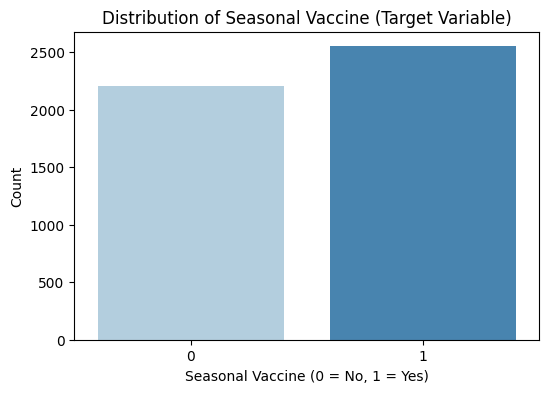

In [219]:
plt.figure(figsize=(6, 4))
sns.countplot(x=target, hue=target, palette='Blues', legend=False)
plt.title('Distribution of Seasonal Vaccine (Target Variable)')
plt.xlabel('Seasonal Vaccine (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

### Seasonal Vaccine by Age Group

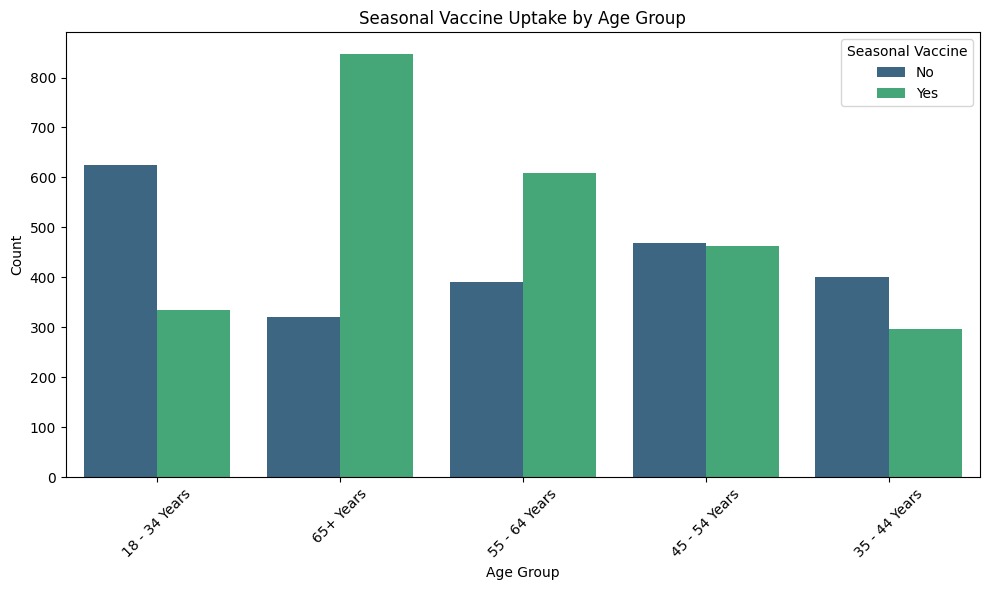

In [220]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='age_group', hue='seasonal_vaccine', palette='viridis')
plt.title('Seasonal Vaccine Uptake by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Seasonal Vaccine', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

### Seasonal Vaccine by Education Level

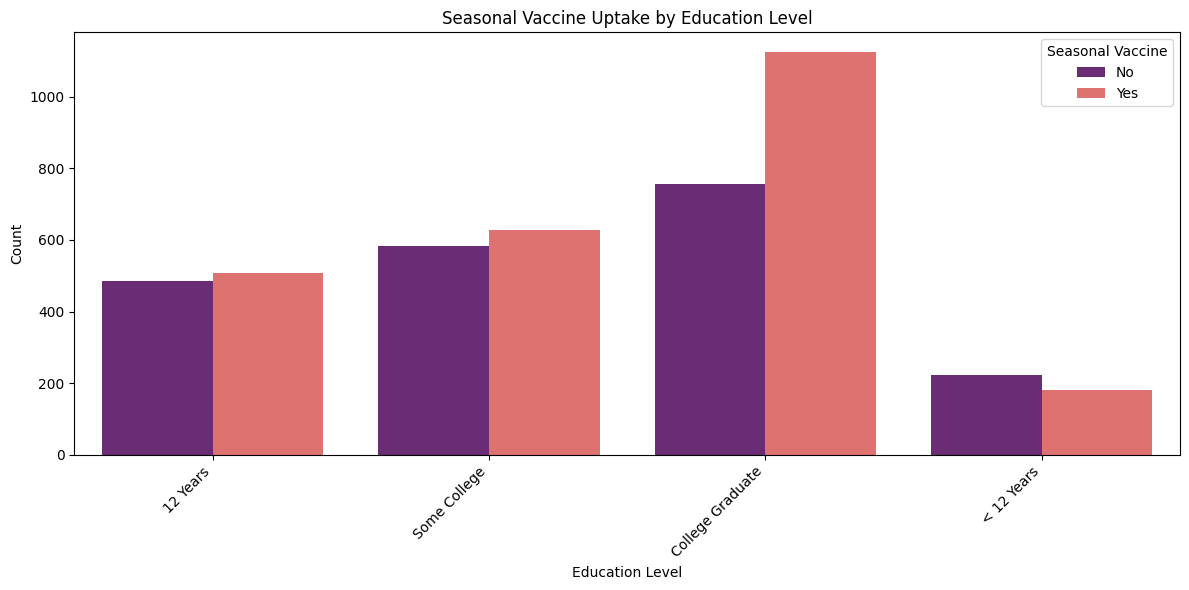

In [221]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='education', hue='seasonal_vaccine', palette='magma')
plt.title('Seasonal Vaccine Uptake by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Seasonal Vaccine', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

### Seasonal Vaccine by Sex

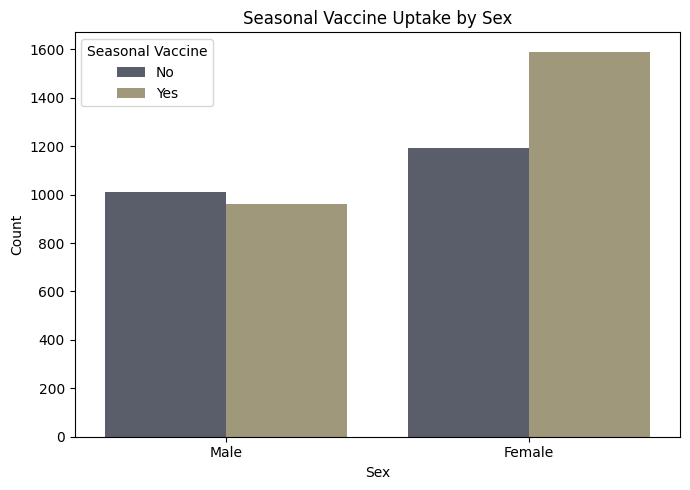

In [222]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='sex', hue='seasonal_vaccine', palette='cividis')
plt.title('Seasonal Vaccine Uptake by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.legend(title='Seasonal Vaccine', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

### Seasonal Vaccine by Income Poverty

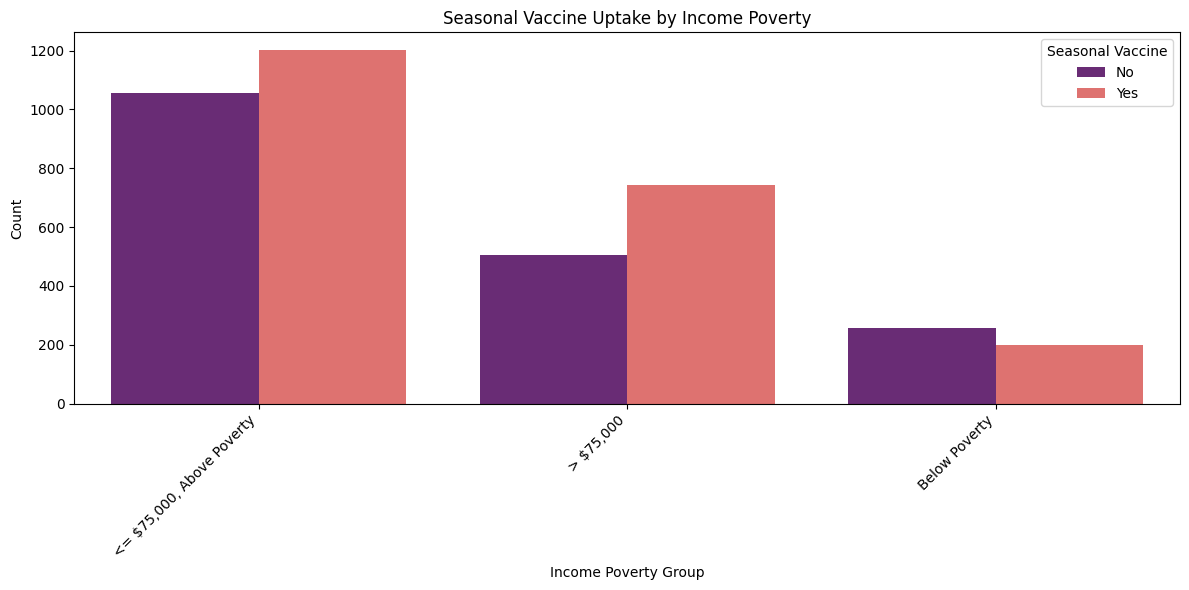

In [223]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='income_poverty', hue='seasonal_vaccine', palette='magma')
plt.title('Seasonal Vaccine Uptake by Income Poverty')
plt.xlabel('Income Poverty Group')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Seasonal Vaccine', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

### Proportion of Seasonal Vaccine Uptake by Age Group

seasonal_vaccine,0,1
age_group,,
18 - 34 Years,65.104167,34.895833
35 - 44 Years,57.388809,42.611191
45 - 54 Years,50.268528,49.731472
55 - 64 Years,39.139139,60.860861
65+ Years,27.459367,72.540633


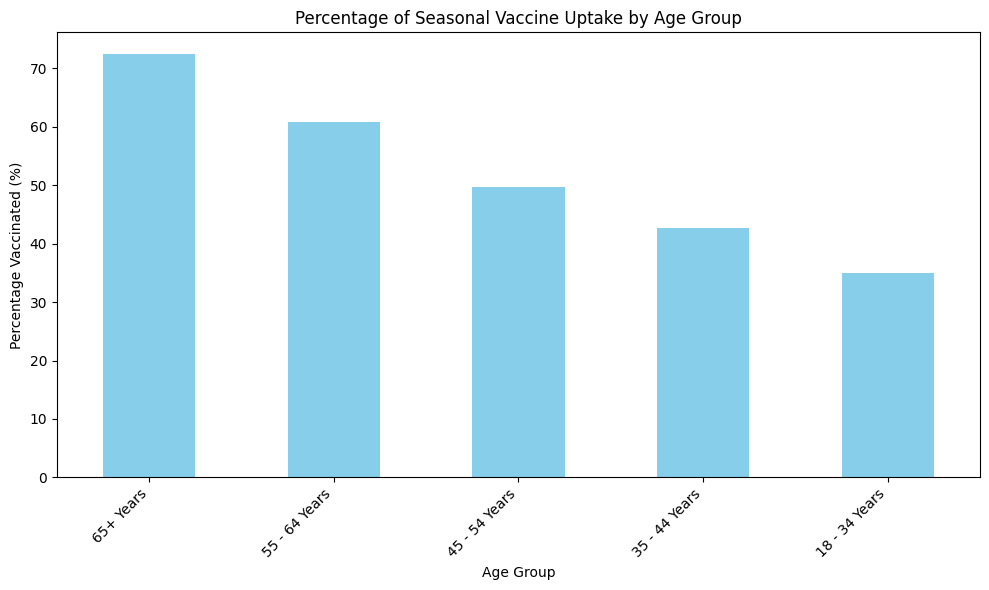

In [224]:
age_group_seasonal_vaccine = df.groupby('age_group')['seasonal_vaccine'].value_counts(normalize=True).mul(100).unstack().fillna(0)
display(age_group_seasonal_vaccine)

plt.figure(figsize=(10, 6))
age_group_seasonal_vaccine[1].sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title('Percentage of Seasonal Vaccine Uptake by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Percentage Vaccinated (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Proportion of Seasonal Vaccine Uptake by Education Level

seasonal_vaccine,0,1
education,,
12 Years,48.891129,51.108871
< 12 Years,55.172414,44.827586
College Graduate,40.234167,59.765833
Some College,48.138958,51.861042


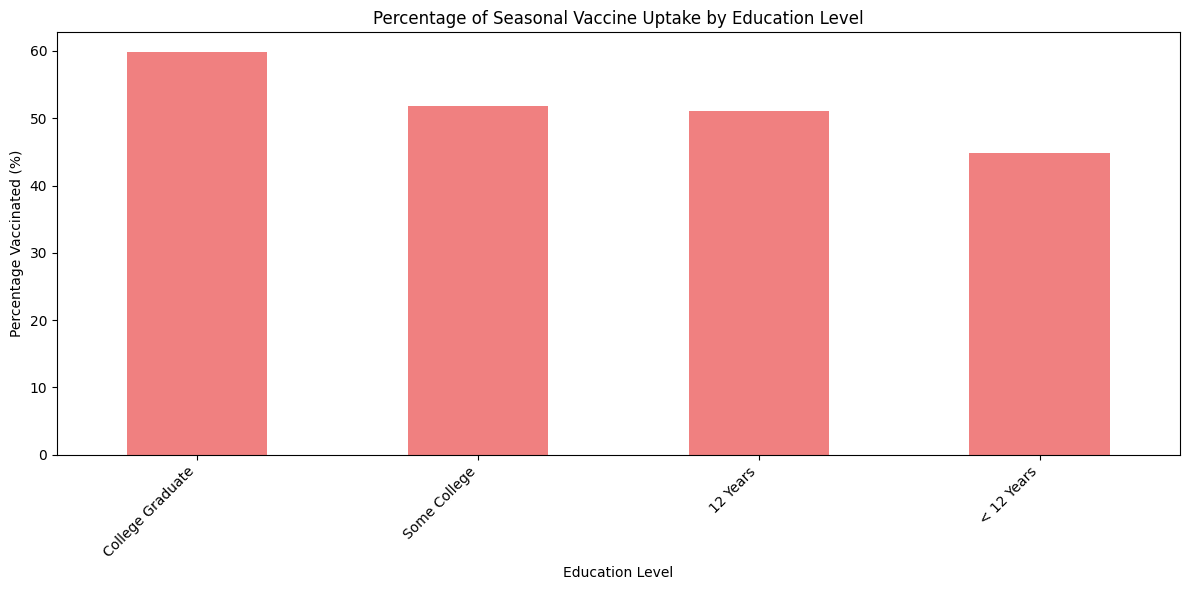

In [225]:
education_seasonal_vaccine = df.groupby('education')['seasonal_vaccine'].value_counts(normalize=True).mul(100).unstack().fillna(0)
display(education_seasonal_vaccine)

plt.figure(figsize=(12, 6))
education_seasonal_vaccine[1].sort_values(ascending=False).plot(kind='bar', color='lightcoral')
plt.title('Percentage of Seasonal Vaccine Uptake by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Percentage Vaccinated (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Proportion of Seasonal Vaccine Uptake by Sex

seasonal_vaccine,0,1
sex,,
Female,42.831477,57.168523
Male,51.343132,48.656868


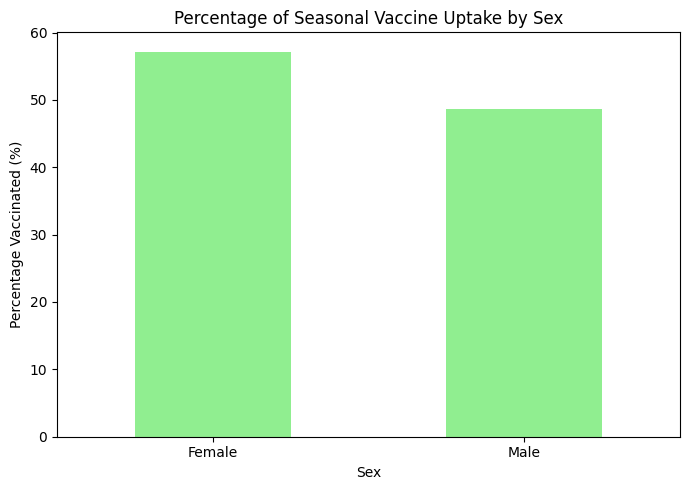

In [226]:
sex_seasonal_vaccine = df.groupby('sex')['seasonal_vaccine'].value_counts(normalize=True).mul(100).unstack().fillna(0)
display(sex_seasonal_vaccine)

plt.figure(figsize=(7, 5))
sex_seasonal_vaccine[1].sort_values(ascending=False).plot(kind='bar', color='lightgreen')
plt.title('Percentage of Seasonal Vaccine Uptake by Sex')
plt.xlabel('Sex')
plt.ylabel('Percentage Vaccinated (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Proportion of Seasonal Vaccine Uptake by Income Poverty

seasonal_vaccine,0,1
income_poverty,,
"<= $75,000, Above Poverty",46.767050,53.232950
"> $75,000",40.480000,59.520000
Below Poverty,56.331878,43.668122


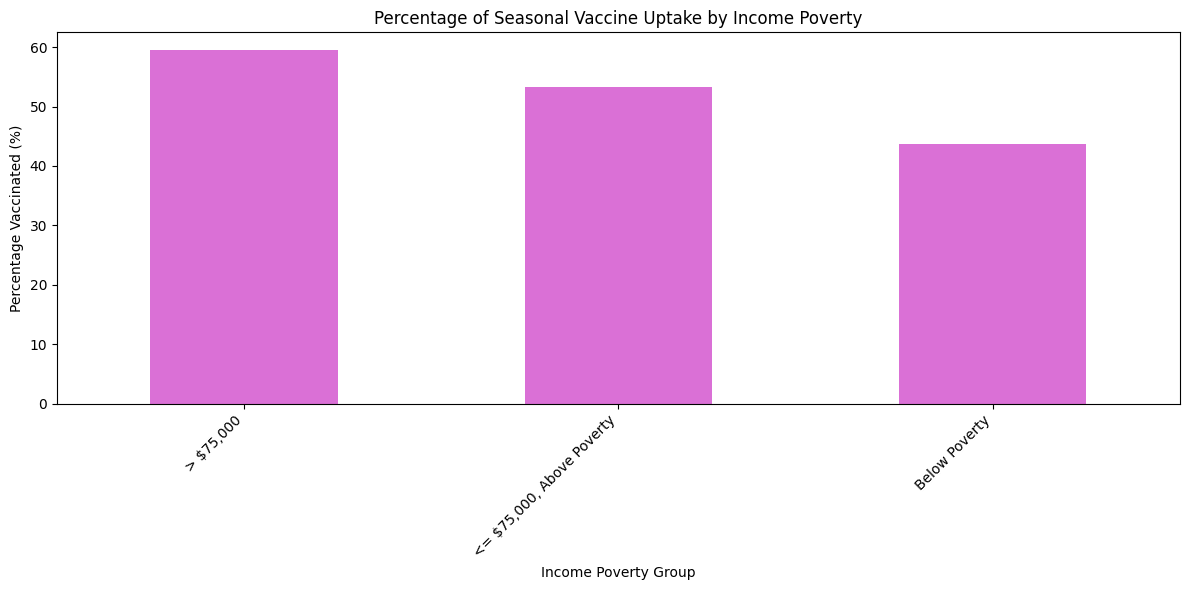

In [227]:
income_poverty_seasonal_vaccine = df.groupby('income_poverty')['seasonal_vaccine'].value_counts(normalize=True).mul(100).unstack().fillna(0)
display(income_poverty_seasonal_vaccine)

plt.figure(figsize=(12, 6))
income_poverty_seasonal_vaccine[1].sort_values(ascending=False).plot(kind='bar', color='orchid')
plt.title('Percentage of Seasonal Vaccine Uptake by Income Poverty')
plt.xlabel('Income Poverty Group')
plt.ylabel('Percentage Vaccinated (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Proportion of Seasonal Vaccine Uptake by Flu Concern

seasonal_vaccine,0,1
flu_concern,,
0.0,64.212329,35.787671
1.0,51.888810,48.111190
2.0,40.393827,59.606173
3.0,38.382688,61.617312


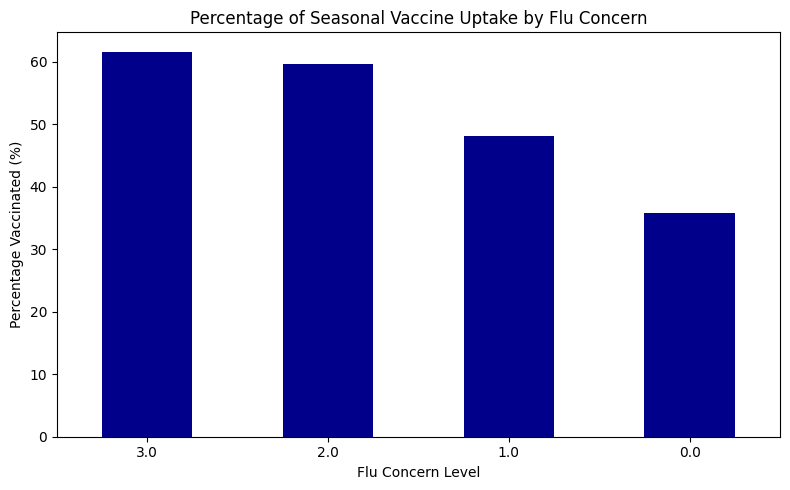

In [228]:
flu_concern_seasonal_vaccine = df.groupby('flu_concern')['seasonal_vaccine'].value_counts(normalize=True).mul(100).unstack().fillna(0)
display(flu_concern_seasonal_vaccine)

plt.figure(figsize=(8, 5))
flu_concern_seasonal_vaccine[1].sort_values(ascending=False).plot(kind='bar', color='darkblue')
plt.title('Percentage of Seasonal Vaccine Uptake by Flu Concern')
plt.xlabel('Flu Concern Level')
plt.ylabel('Percentage Vaccinated (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Proportion of Seasonal Vaccine Uptake by Doctor's Recommendation

seasonal_vaccine,0,1
doctor_recc_seasonal,,
0.0,58.963283,41.036717
1.0,22.450211,77.549789


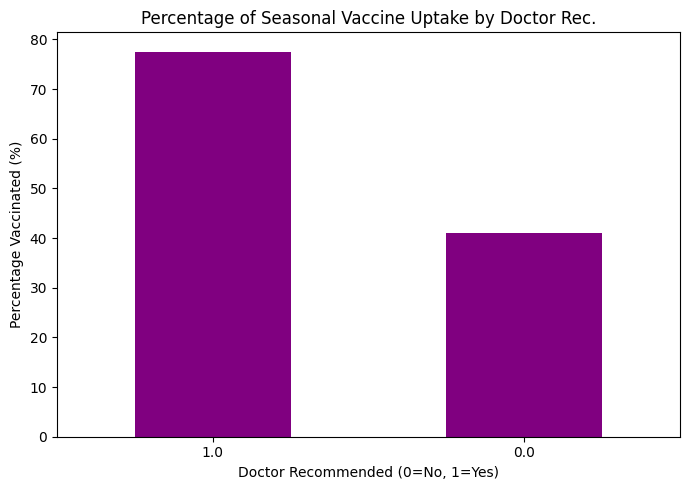

In [229]:
doctor_recc_seasonal_vaccine = df.groupby('doctor_recc_seasonal')['seasonal_vaccine'].value_counts(normalize=True).mul(100).unstack().fillna(0)
display(doctor_recc_seasonal_vaccine)

plt.figure(figsize=(7, 5))
doctor_recc_seasonal_vaccine[1].sort_values(ascending=False).plot(kind='bar', color='purple')
plt.title('Percentage of Seasonal Vaccine Uptake by Doctor Rec.')
plt.xlabel('Doctor Recommended (0=No, 1=Yes)')
plt.ylabel('Percentage Vaccinated (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Proportion of Seasonal Vaccine Uptake by Opinion on Vaccine Effectiveness

seasonal_vaccine,0,1
opinion_seas_vacc_effective,,
1.0,75.598086,24.401914
2.0,83.190883,16.809117
3.0,64.397906,35.602094
4.0,55.441478,44.558522
5.0,25.063678,74.936322


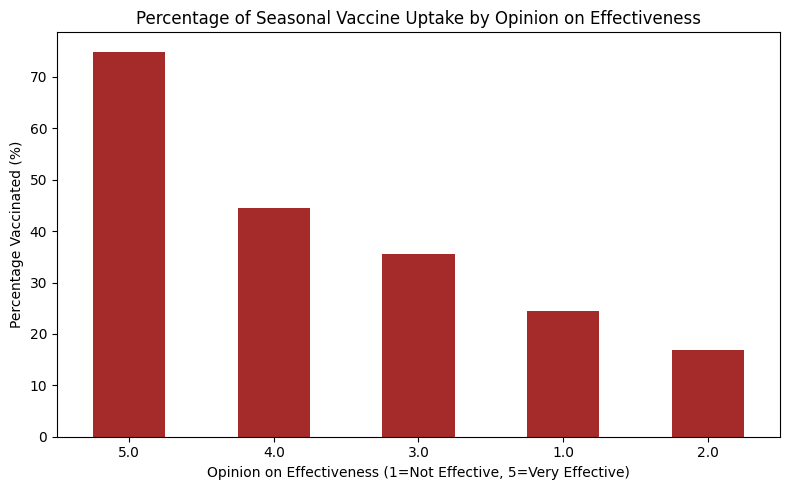

In [230]:
opinion_seas_vacc_effective_seasonal_vaccine = df.groupby('opinion_seas_vacc_effective')['seasonal_vaccine'].value_counts(normalize=True).mul(100).unstack().fillna(0)
display(opinion_seas_vacc_effective_seasonal_vaccine)

plt.figure(figsize=(8, 5))
opinion_seas_vacc_effective_seasonal_vaccine[1].sort_values(ascending=False).plot(kind='bar', color='brown')
plt.title('Percentage of Seasonal Vaccine Uptake by Opinion on Effectiveness')
plt.xlabel('Opinion on Effectiveness (1=Not Effective, 5=Very Effective)')
plt.ylabel('Percentage Vaccinated (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Proportion of Seasonal Vaccine Uptake by Opinion on Seasonal Flu Risk

seasonal_vaccine,0,1
opinion_seas_risk,,
1.0,75.617615,24.382385
2.0,56.548019,43.451981
3.0,32.500000,67.500000
4.0,28.689655,71.310345
5.0,21.385542,78.614458


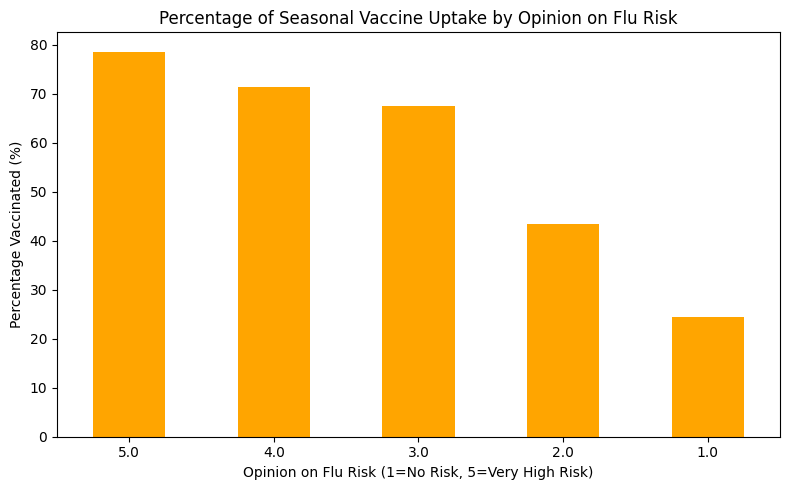

In [231]:
opinion_seas_risk_seasonal_vaccine = df.groupby('opinion_seas_risk')['seasonal_vaccine'].value_counts(normalize=True).mul(100).unstack().fillna(0)
display(opinion_seas_risk_seasonal_vaccine)

plt.figure(figsize=(8, 5))
opinion_seas_risk_seasonal_vaccine[1].sort_values(ascending=False).plot(kind='bar', color='orange')
plt.title('Percentage of Seasonal Vaccine Uptake by Opinion on Flu Risk')
plt.xlabel('Opinion on Flu Risk (1=No Risk, 5=Very High Risk)')
plt.ylabel('Percentage Vaccinated (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Handling Missing Values

In [235]:
# Store non-feature columns (respondent_id and seasonal_vaccine) separately
df_ids_target = df_original[['respondent_id', 'seasonal_vaccine']].copy()
df_features = df_original.drop(columns=['respondent_id', 'seasonal_vaccine']).copy()

# Identify numerical and categorical features in the feature set
numerical_features = df_features.select_dtypes(include=np.number).columns.tolist()
categorical_features = df_features.select_dtypes(exclude=np.number).columns.tolist()

In [236]:
# Create a ColumnTransformer for preprocessing:
# - OneHotEncoder for categorical features (handles NaNs in categorical columns by creating all-zero vectors)
# - 'passthrough' for numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ],
    remainder='drop' # Drop any columns not specified in transformers
)

In [238]:
# Create a MICE imputation pipeline
mice_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('imputer', IterativeImputer(max_iter=10, random_state=0)) # IterativeImputer for MICE
])

# Fit and transform the data using the MICE pipeline
df_imputed_array = mice_pipeline.fit_transform(df_features)

# Get feature names after preprocessing
ohe_feature_names = mice_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
num_feature_names = mice_pipeline.named_steps['preprocessor'].named_transformers_['num'].get_feature_names_out(numerical_features)

all_processed_feature_names = list(ohe_feature_names) + list(num_feature_names)

# Convert the imputed array back to a DataFrame
df_imputed_processed = pd.DataFrame(df_imputed_array, columns=all_processed_feature_names, index=df_original.index)

# Reconstruct original categorical columns from one-hot encoded and imputed values
# The MICE imputer might output float values for one-hot encoded columns. We'll convert them back
# to categorical strings by selecting the category with the highest imputed value.
df_mice_final = df_imputed_processed.copy()

for original_cat_col in categorical_features:
    ohe_cols_for_cat = [col for col in df_imputed_processed.columns if col.startswith(f"{original_cat_col}_")]

    if ohe_cols_for_cat:
        # Determine the category based on the highest imputed value (treating as probability)
        df_mice_final[original_cat_col] = df_imputed_processed[ohe_cols_for_cat].idxmax(axis=1).apply(lambda x: x.split(f"{original_cat_col}_")[1])
        # Drop the individual one-hot encoded columns
        df_mice_final = df_mice_final.drop(columns=ohe_cols_for_cat)

# Reorder columns to match the original structure (numerical then categorical features)
df_mice_final = df_mice_final[numerical_features + categorical_features]

# Re-attach 'respondent_id' and 'seasonal_vaccine'
df_mice_final['respondent_id'] = df_ids_target['respondent_id']
df_mice_final['seasonal_vaccine'] = df_ids_target['seasonal_vaccine']

# Assign the final imputed DataFrame to 'df'
df = df_mice_final

print("Missing values after MICE imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nDataFrame head after MICE imputation:")
print(df.head())

Missing values after MICE imputation:
Series([], dtype: int64)

DataFrame head after MICE imputation:
   flu_concern  flu_knowledge  behavioral_antiviral_meds  \
0          2.0            0.0                        0.0   
1          1.0            1.0                        0.0   
2          2.0            1.0                        0.0   
3          1.0            2.0                        0.0   
4          2.0            2.0                        0.0   

   behavioral_avoidance  behavioral_face_mask  behavioral_wash_hands  \
0                   1.0                   0.0                    1.0   
1                   1.0                   0.0                    0.0   
2                   1.0                   0.0                    1.0   
3                   1.0                   0.0                    1.0   
4                   1.0                   0.0                    1.0   

   behavioral_large_gatherings  behavioral_outside_home  \
0                          1.0               

### Statistical Summary Before MICE Imputation

In [239]:
print("Statistical summary of df_original (before MICE imputation):")
display(df_original.describe(include='all'))

print("\nMissing values in df_original (before MICE imputation):")
print(df_original.isnull().sum()[df_original.isnull().sum() > 0])

Statistical summary of df_original (before MICE imputation):


,respondent_id,flu_concern,flu_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,seasonal_vaccine
count,4756.00000,4744.000000,4733.000000,4742.000000,4724.000000,4753.000000,4748.000000,4747.000000,4747.000000,4737.000000,...,4756,3966,4491,4375,4487,4756,4712.000000,4712.000000,2442,4756.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2,3,2,2,3,3,NaN,NaN,21,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Female,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",NaN,NaN,healthcare,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2783,2258,2403,3292,2467,2059,NaN,NaN,511,NaN
mean,2378.50000,1.643128,1.293049,0.052299,0.734124,0.073848,0.836563,0.365494,0.336634,0.688410,...,NaN,NaN,NaN,NaN,NaN,NaN,0.895586,0.541596,NaN,0.536375
std,1373.08327,0.919810,0.618902,0.222652,0.441846,0.261551,0.369803,0.481619,0.472608,0.463192,...,NaN,NaN,NaN,NaN,NaN,NaN,0.759658,0.936970,NaN,0.498728
min,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,0.000000
25%,1189.75000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,0.000000
50%,2378.50000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,NaN,1.000000
75%,3567.25000,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN,1.000000



Missing values in df_original (before MICE imputation):
flu_concern                      12
flu_knowledge                    23
behavioral_antiviral_meds        14
behavioral_avoidance             32
behavioral_face_mask              3
behavioral_wash_hands             8
behavioral_large_gatherings       9
behavioral_outside_home           9
behavioral_touch_face            19
doctor_recc_seasonal            321
chronic_med_condition           188
child_under_6_months            152
health_worker                   149
health_insurance               1925
opinion_seas_vacc_effective      94
opinion_seas_risk               102
opinion_seas_sick_from_vacc     101
education                       270
income_poverty                  790
marital_status                  265
rent_or_own                     381
employment_status               269
household_adults                 44
household_children               44
employment_sector              2314
dtype: int64


### Statistical Summary After MICE Imputation

In [240]:
print("Statistical summary of df (after MICE imputation):")
display(df.describe(include='all'))

print("\nMissing values in df (after MICE imputation):")
print(df.isnull().sum()[df.isnull().sum() > 0])

Statistical summary of df (after MICE imputation):


,flu_concern,flu_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_seasonal,...,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,employment_sector,respondent_id,seasonal_vaccine
count,4756.000000,4756.000000,4756.000000,4756.000000,4756.000000,4756.000000,4756.000000,4756.000000,4756.000000,4756.000000,...,4756,4756,4756,4756,4756,4756,4756,4756,4756.00000,4756.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4,2,4,3,3,4,3,22,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",nan,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3766,2783,2258,2403,3292,2467,2059,2314,NaN,NaN
mean,1.642605,1.291786,0.052338,0.733640,0.073833,0.836363,0.365589,0.336471,0.688398,0.371247,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2378.50000,0.536375
std,0.918923,0.617959,0.222339,0.440606,0.261473,0.369576,0.481328,0.472261,0.462425,0.469260,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1373.08327,0.498728
min,0.000000,0.000000,-0.021940,0.000000,0.000000,0.000000,-0.016785,0.000000,0.000000,-0.063363,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00000,0.000000
25%,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1189.75000,0.000000
50%,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2378.50000,1.000000
75%,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3567.25000,1.000000



Missing values in df (after MICE imputation):
Series([], dtype: int64)


### Split the Data into Training and Testing Sets

In [244]:
# Separate features (X) and target (y)
X = df.drop(['seasonal_vaccine', 'respondent_id'], axis=1)
y = df['seasonal_vaccine']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (3804, 29)
X_test shape: (952, 29)
y_train shape: (3804,)
y_test shape: (952,)


### One-Hot Encode Categorical Features for Model Training

In [245]:
# Identify categorical features in X_train
categorical_features = X_train.select_dtypes(include='object').columns.tolist()

# Create a ColumnTransformer to apply OneHotEncoder to categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep numerical features
)

# Fit the preprocessor on X_train and transform both X_train and X_test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get feature names after one-hot encoding
ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
remaining_features = [col for col in X_train.columns if col not in categorical_features]
all_feature_names = list(ohe_feature_names) + remaining_features

# Sanitize feature names for XGBoost compatibility
def sanitize_feature_names(names):
    sanitized_names = []
    for name in names:
        # Replace problematic characters with underscores
        sanitized_name = re.sub(r'[^a-zA-Z0-9_]', '_', name)
        # Remove any leading/trailing underscores and replace multiple underscores with a single one
        sanitized_name = re.sub(r'_+', '_', sanitized_name).strip('_')
        sanitized_names.append(sanitized_name)
    return sanitized_names

all_feature_names_sanitized = sanitize_feature_names(all_feature_names)

# Convert the processed arrays back to DataFrames
X_train_processed_df = pd.DataFrame(X_train_processed, columns=all_feature_names_sanitized, index=X_train.index)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=all_feature_names_sanitized, index=X_test.index)

print("Shape of X_train after one-hot encoding and sanitizing:", X_train_processed_df.shape)
print("Shape of X_test after one-hot encoding and sanitizing:", X_test_processed_df.shape)
print("\nFirst 5 rows of X_train_processed_df:")
display(X_train_processed_df.head())

Shape of X_train after one-hot encoding and sanitizing: (3804, 74)
Shape of X_test after one-hot encoding and sanitizing: (952, 74)

First 5 rows of X_train_processed_df:


,age_group_18_34_Years,age_group_35_44_Years,age_group_45_54_Years,age_group_55_64_Years,age_group_65_Years,education_12_Years,education_12_Years,education_College_Graduate,education_Some_College,education_nan,...,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children
2190,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,1.000000,4.0,2.0,1.0,0.0,0.0
728,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,1.000000,5.0,1.0,1.0,0.0,0.0
3865,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.000000,1.0,0.0,0.0,0.924354,5.0,4.0,1.0,0.0,0.0
109,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.301462,0.0,0.0,0.0,1.000000,4.0,3.0,4.0,0.0,0.0
1216,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.581997,1.0,0.0,0.0,1.037934,4.0,4.0,1.0,0.0,0.0


### Train an XGBoost Classifier and Evaluate Performance

In [246]:
import xgboost as xgb

# Initialize the XGBoost Classifier
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight_value = neg_count / pos_count

model_xgb = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    random_state=42,
    scale_pos_weight=scale_pos_weight_value
)

# Train the model
# Use the sanitized DataFrames' underlying NumPy arrays for fitting
model_xgb.fit(X_train_processed_df.values, y_train)

# Make predictions on the test set
# Use the sanitized DataFrames' underlying NumPy arrays for prediction
y_pred_xgb = model_xgb.predict(X_test_processed_df.values)

# Evaluate the model
print("XGBoost Classifier Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Classifier Performance:
Accuracy: 0.7878151260504201
F1 Score: 0.795959595959596

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.81      0.78       441
           1       0.82      0.77      0.80       511

    accuracy                           0.79       952
   macro avg       0.79      0.79      0.79       952
weighted avg       0.79      0.79      0.79       952



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:21:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### Hyperparameter Tuning for XGBoost using GridSearchCV

To further improve the F1 score, we will perform hyperparameter tuning using `GridSearchCV`. This method systematically works through multiple combinations of parameter values, cross-validating each combination to determine which set performs best.

In [247]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
# We'll start with a focused grid to keep computation reasonable.
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'gamma': [0, 0.1, 0.2]
}

# Initialize the XGBoost Classifier with best known settings for other parameters
# Retain scale_pos_weight from previous analysis to handle class imbalance
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight_value = neg_count / pos_count

model_xgb_base = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    scale_pos_weight=scale_pos_weight_value,
    subsample=0.8, # Keep previous good value
    colsample_bytree=0.8 # Keep previous good value
)

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=model_xgb_base,
    param_grid=param_grid,
    scoring='f1', # Optimize for F1 score
    cv=3,         # 3-fold cross-validation
    verbose=2,    # Show progress
    n_jobs=-1     # Use all available CPU cores
)

# Fit GridSearchCV to the training data
# Use the sanitized DataFrames' underlying NumPy arrays for fitting
grid_search.fit(X_train_processed_df.values, y_train)

print(f"Best hyperparameters: {grid_search.best_params_}")
print(f"Best F1 score from cross-validation: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best hyperparameters: {'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
Best F1 score from cross-validation: 0.7902


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:22:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### Evaluate the Best Model from Hyperparameter Tuning

Now, let's evaluate the performance of the XGBoost model with the best hyperparameters found by `GridSearchCV` on the held-out test set.

In [248]:
# Get the best model found by GridSearchCV
best_xgb_model = grid_search.best_estimator_

# Make predictions on the test set using the best model
y_pred_tuned_xgb = best_xgb_model.predict(X_test_processed_df.values)

# Evaluate the tuned model
print("XGBoost Classifier Performance (after Hyperparameter Tuning):")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned_xgb))
print("F1 Score:", f1_score(y_test, y_pred_tuned_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned_xgb))

XGBoost Classifier Performance (after Hyperparameter Tuning):
Accuracy: 0.7804621848739496
F1 Score: 0.7912087912087912

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.79      0.77       441
           1       0.81      0.77      0.79       511

    accuracy                           0.78       952
   macro avg       0.78      0.78      0.78       952
weighted avg       0.78      0.78      0.78       952



### Advanced Hyperparameter Tuning with RandomizedSearchCV

Since the previous `GridSearchCV` with a limited grid did not significantly improve the F1 score, let's try a more extensive search using `RandomizedSearchCV`. This method explores a fixed number of parameter settings from specified distributions, which is more computationally efficient for larger search spaces and can often find good solutions faster than exhaustive grid search.

In [249]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Define a broader and more extensive parameter distribution for RandomizedSearchCV
param_distributions = {
    'n_estimators': randint(50, 500), # Number of boosting rounds
    'learning_rate': uniform(0.01, 0.3), # Step size shrinkage
    'max_depth': randint(3, 10),      # Maximum depth of a tree
    'subsample': uniform(0.6, 0.4),   # Subsample ratio of the training instance (e.g., 0.6 to 1.0)
    'colsample_bytree': uniform(0.6, 0.4), # Subsample ratio of columns (e.g., 0.6 to 1.0)
    'gamma': uniform(0, 0.5)          # Minimum loss reduction for a split
}

# Initialize the XGBoost Classifier with best known settings for other parameters
# Retain scale_pos_weight for class imbalance
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight_value = neg_count / pos_count

model_xgb_base_rand = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    scale_pos_weight=scale_pos_weight_value
)

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=model_xgb_base_rand,
    param_distributions=param_distributions,
    n_iter=50, # Number of parameter settings that are sampled. More is better but takes longer.
    scoring='f1', # Optimize for F1 score
    cv=3,         # 3-fold cross-validation
    verbose=2,    # Show progress
    random_state=42, # For reproducibility
    n_jobs=-1     # Use all available CPU cores
)

# Fit RandomizedSearchCV to the training data
random_search.fit(X_train_processed_df.values, y_train)

print(f"Best hyperparameters from RandomizedSearchCV: {random_search.best_params_}")
print(f"Best F1 score from cross-validation (RandomizedSearchCV): {random_search.best_score_:.4f}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best hyperparameters from RandomizedSearchCV: {'colsample_bytree': np.float64(0.7114585856946446), 'gamma': np.float64(0.45413294298332685), 'learning_rate': np.float64(0.08186856720009172), 'max_depth': 4, 'n_estimators': 102, 'subsample': np.float64(0.7957811041110252)}
Best F1 score from cross-validation (RandomizedSearchCV): 0.7879


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:23:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### Evaluate the Best Model from RandomizedSearchCV

Let's evaluate the performance of the XGBoost model with the best hyperparameters found by `RandomizedSearchCV` on the held-out test set.

In [250]:
# Get the best model found by RandomizedSearchCV
best_xgb_model_rand = random_search.best_estimator_

# Make predictions on the test set using the best model
y_pred_tuned_xgb_rand = best_xgb_model_rand.predict(X_test_processed_df.values)

# Evaluate the tuned model
print("XGBoost Classifier Performance (after RandomizedSearchCV Tuning):")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned_xgb_rand))
print("F1 Score:", f1_score(y_test, y_pred_tuned_xgb_rand))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned_xgb_rand))

XGBoost Classifier Performance (after RandomizedSearchCV Tuning):
Accuracy: 0.7888655462184874
F1 Score: 0.79839518555667

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.80      0.78       441
           1       0.82      0.78      0.80       511

    accuracy                           0.79       952
   macro avg       0.79      0.79      0.79       952
weighted avg       0.79      0.79      0.79       952



### Generating Predictions with the Best Tuned XGBoost Model on the External Test Dataset

Now that we have the best performing model after `RandomizedSearchCV`, we will use it to generate predictions on the external testing dataset (`dataset_A_testing.csv`) and save them to a submission file.

In [253]:
import pandas as pd
import numpy as np

# 1. Load the original testing dataset
test_datapath = "/content/dataset_A_testing.csv"
df_new_test_original_tuned = pd.read_csv(test_datapath)

print("Original Testing Dataset Head (for tuned model predictions):")
display(df_new_test_original_tuned.head())

# 2. Separate respondent_id and prepare features
test_ids_tuned = df_new_test_original_tuned['respondent_id']
df_new_test_features_tuned = df_new_test_original_tuned.drop(columns=['respondent_id'])

# 3. Apply MICE Imputation using the already fitted mice_pipeline
# The `mice_pipeline` includes the first OHE for categorical features and the IterativeImputer.
# `all_processed_feature_names` are the column names after the first OHE within the mice_pipeline.
df_new_test_imputed_array_tuned = mice_pipeline.transform(df_new_test_features_tuned)
df_new_test_imputed_processed_tuned = pd.DataFrame(
    df_new_test_imputed_array_tuned,
    columns=all_processed_feature_names,
    index=df_new_test_original_tuned.index
)

# 4. Reconstruct original categorical columns from one-hot encoded and imputed values
df_new_test_mice_final_tuned = df_new_test_imputed_processed_tuned.copy()

original_categorical_features_mice = [col for col in categorical_features if col in df_new_test_features_tuned.columns]

for original_cat_col in original_categorical_features_mice:
    ohe_cols_for_cat = [col for col in df_new_test_imputed_processed_tuned.columns if col.startswith(f"{original_cat_col}_")]
    if ohe_cols_for_cat:
        df_new_test_mice_final_tuned[original_cat_col] = df_new_test_imputed_processed_tuned[ohe_cols_for_cat].idxmax(axis=1).apply(lambda x: x.split(f"{original_cat_col}_")[1])
        df_new_test_mice_final_tuned = df_new_test_mice_final_tuned.drop(columns=ohe_cols_for_cat)

final_features_for_second_ohe_tuned = df_new_test_mice_final_tuned[numerical_features + original_categorical_features_mice]

print("\nProcessed Test Features (after MICE and reconstruction, for tuned model) Head:")
display(final_features_for_second_ohe_tuned.head())

# 5. Apply the second One-Hot Encoder and feature sanitization (fitted on X_train)
X_new_test_processed_tuned_df = pd.DataFrame(
    preprocessor.transform(final_features_for_second_ohe_tuned),
    columns=all_feature_names_sanitized,
    index=df_new_test_original_tuned.index
)

print("\nFinal Processed Test Data for Tuned XGBoost Head:")
display(X_new_test_processed_tuned_df.head())
print(f"Shape of final processed test data (for tuned model): {X_new_test_processed_tuned_df.shape}")

# 6. Make predictions using the best_xgb_model_rand (the model from RandomizedSearchCV)
new_test_predictions_tuned = best_xgb_model_rand.predict(X_new_test_processed_tuned_df.values)

# 7. Create submission DataFrame
submission_df_tuned = pd.DataFrame({
    'respondent_id': test_ids_tuned,
    'seasonal_vaccine': new_test_predictions_tuned
})

print("\nPredictions on the original testing dataset (from tuned model):")
display(submission_df_tuned.head())

print(f"Number of seasonal vaccine predictions (1): {submission_df_tuned['seasonal_vaccine'].sum()}")
print(f"Number of no seasonal vaccine predictions (0): {len(submission_df_tuned) - submission_df_tuned['seasonal_vaccine'].sum()}")

Original Testing Dataset Head (for tuned model predictions):


,respondent_id,flu_concern,flu_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector
0,4757,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,White,Female,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,"MSA, Principle City",0.0,0.0,NaN
1,4758,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,White,Female,NaN,NaN,NaN,NaN,"MSA, Not Principle City",0.0,0.0,NaN
2,4759,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,White,Male,NaN,Married,Own,Not in Labor Force,"MSA, Principle City",1.0,0.0,NaN
3,4760,3.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,1.0,0.0,agriculture
4,4761,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,Non-MSA,0.0,0.0,wholesale



Processed Test Features (after MICE and reconstruction, for tuned model) Head:


,flu_concern,flu_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_seasonal,...,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,employment_sector
0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,65+ Years,12 Years,White,Female,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,"MSA, Principle City",nan
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,65+ Years,nan,White,Female,nan,nan,nan,nan,"MSA, Not Principle City",nan
2,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,65+ Years,College Graduate,White,Male,nan,Married,Own,Not in Labor Force,"MSA, Principle City",nan
3,3.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,55 - 64 Years,12 Years,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,agriculture
4,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,35 - 44 Years,Some College,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,Non-MSA,wholesale



Final Processed Test Data for Tuned XGBoost Head:


,age_group_18_34_Years,age_group_35_44_Years,age_group_45_54_Years,age_group_55_64_Years,age_group_65_Years,education_12_Years,education_12_Years,education_College_Graduate,education_Some_College,education_nan,...,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children
0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,1.000000,4.0,2.0,2.0,0.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.392501,0.064411,0.124461,0.974544,4.0,3.0,2.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,1.000000,5.0,4.0,2.0,1.0,0.0
3,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.000000,0.000000,0.000000,1.000000,5.0,5.0,1.0,1.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.000000,0.000000,0.000000,1.000000,4.0,2.0,1.0,0.0,0.0


Shape of final processed test data (for tuned model): (4749, 74)

Predictions on the original testing dataset (from tuned model):


,respondent_id,seasonal_vaccine
0,4757,0
1,4758,1
2,4759,1
3,4760,1
4,4761,0


Number of seasonal vaccine predictions (1): 2517
Number of no seasonal vaccine predictions (0): 2232


In [255]:
# 8. Save the new predictions to a CSV file
submission_df_tuned.to_csv('submission_tuned.csv', index=False)
print("New predictions from the tuned model saved to submission_tuned.csv")

print('\nHead of your new generated submission_tuned.csv:')
submission_tuned_df_check = pd.read_csv('submission_tuned.csv')
display(submission_tuned_df_check.head())


New predictions from the tuned model saved to submission_tuned.csv

Head of your new generated submission_tuned.csv:


,respondent_id,seasonal_vaccine
0,4757,0
1,4758,1
2,4759,1
3,4760,1
4,4761,0
